# Linear Regression

## Objective

The objective of this study is to investigate whether the variable **predicted_energy_demand** can be estimated using a linear relationship with other building and environmental parameters.

According to the lecture notes, Linear Regression assumes that the response variable can be expressed as a linear combination of the predictor variables together with a random noise component.

This assignment aims to identify suitable predictor variables, construct a linear regression model, evaluate its performance, and discuss whether a linear model is appropriate for predicting building energy demand.

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Dataset Acquisition

The dataset is downloaded from Kaggle.

In [24]:
import os
import kagglehub

# Download the latest version of the dataset using kagglehub
kagglepath="programmer3/green-building-multi-source-environment-dataset"

path = kagglehub.dataset_download(kagglepath)

print("Path to dataset files:", path)


# List contents to ensure the correct filename exists
print(f"Listing contents of: {path}")
!ls {path}

# Read the CSV file into a pandas dataframe
df2 = pd.read_csv(path+"/green_building_dataset.csv")

Using Colab cache for faster access to the 'green-building-multi-source-environment-dataset' dataset.
Path to dataset files: /kaggle/input/green-building-multi-source-environment-dataset
Listing contents of: /kaggle/input/green-building-multi-source-environment-dataset
green_building_dataset.csv


## Dataset Overview

The dataset contains building operation and environmental variables that may influence building energy consumption.

Before constructing a linear regression model, the structure of the dataset is examined.

In [25]:
# Display first five rows
df2.head()

,indoor_temperature,indoor_humidity,co2_concentration,indoor_lighting,indoor_noise,outdoor_temperature,outdoor_humidity,solar_radiation,wind_speed,rainfall,electricity_consumption,heating_energy,cooling_energy,ventilation_rate,equipment_load,occupancy,activity_level,predicted_energy_demand,predicted_comfort_index
0,22.494481,43.624167,554.345944,432.115959,30.958646,24.443784,22.670752,540.768233,0.333310,47.820981,34.276401,18.919498,21.254016,327.046999,29.348868,26,0,39.936909,0.234932
1,29.408572,32.868476,466.383802,221.965186,68.624892,-1.398534,50.087239,699.959413,5.054747,43.364194,23.378548,17.726091,18.000948,144.862778,26.654788,7,0,24.985061,0.000000
2,26.783927,46.385156,1850.558681,566.559664,38.547245,5.904842,24.415262,828.108509,12.980562,36.379122,2.785345,19.930580,39.099193,493.647357,24.212357,43,1,39.675344,0.000000
3,25.183902,42.448700,663.712464,201.348306,32.195231,29.815571,75.240077,791.541006,0.652026,3.769213,45.925508,17.374061,37.267514,475.091197,6.281035,3,1,52.678350,0.000000
4,19.872224,57.084826,1705.062755,940.588677,62.684935,18.790863,57.069417,882.605624,6.433936,2.452494,49.016457,21.653203,45.261246,287.220492,4.693055,20,3,48.824527,0.000000


In [26]:
# Display information about columns, data types and missing values
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   indoor_temperature       2400 non-null   float64
 1   indoor_humidity          2400 non-null   float64
 2   co2_concentration        2400 non-null   float64
 3   indoor_lighting          2400 non-null   float64
 4   indoor_noise             2400 non-null   float64
 5   outdoor_temperature      2400 non-null   float64
 6   outdoor_humidity         2400 non-null   float64
 7   solar_radiation          2400 non-null   float64
 8   wind_speed               2400 non-null   float64
 9   rainfall                 2400 non-null   float64
 10  electricity_consumption  2400 non-null   float64
 11  heating_energy           2400 non-null   float64
 12  cooling_energy           2400 non-null   float64
 13  ventilation_rate         2400 non-null   float64
 14  equipment_load          

In [27]:
# Display statistical summary of numerical variables
df2.describe()

,indoor_temperature,indoor_humidity,co2_concentration,indoor_lighting,indoor_noise,outdoor_temperature,outdoor_humidity,solar_radiation,wind_speed,rainfall,electricity_consumption,heating_energy,cooling_energy,ventilation_rate,equipment_load,occupancy,activity_level,predicted_energy_demand,predicted_comfort_index
count,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000
mean,23.983870,49.790705,1170.150558,537.938849,55.157072,17.297311,55.186854,512.313662,7.615605,25.774823,24.796787,19.557364,24.980710,249.322350,14.839245,24.863333,1.503750,33.724789,0.001330
std,3.494409,11.514037,476.676518,254.252073,14.537491,13.163134,20.086905,286.687214,4.346765,14.407992,14.229819,11.461431,14.405205,144.429508,8.620437,14.537201,1.126061,9.560419,0.012970
min,18.018781,30.000465,350.397658,100.047544,30.007887,-4.945837,20.017672,0.611635,0.014985,0.002406,0.005512,0.005006,0.003375,0.199846,0.000166,0.000000,0.000000,1.831555,0.000000
25%,20.900275,39.940031,753.792246,325.956124,42.558186,5.647292,37.982148,268.639365,3.909123,13.733789,12.651079,9.458481,12.813325,122.670289,7.255240,12.750000,0.000000,27.114764,0.000000
50%,24.089278,49.697217,1156.849445,532.777499,55.088203,16.964253,55.392092,519.415412,7.667388,25.807678,24.760944,19.643330,25.090347,251.389623,14.872126,25.000000,2.000000,33.577877,0.000000
75%,26.988393,59.681864,1592.308520,747.543049,67.975269,29.046823,72.630587,753.235164,11.313872,38.342784,36.686875,29.188313,37.667744,369.692475,22.170251,37.000000,3.000000,40.417122,0.000000
max,29.996612,69.982308,1999.110124,999.014230,79.983660,39.948017,89.994738,999.871438,14.998515,49.982815,49.972526,39.987824,49.986604,499.848605,29.993681,50.000000,3.000000,58.721555,0.234932


In [21]:
# Display all column names

df2.columns

Index(['indoor_temperature', 'indoor_humidity', 'co2_concentration',
       'indoor_lighting', 'indoor_noise', 'outdoor_temperature',
       'outdoor_humidity', 'solar_radiation', 'wind_speed', 'rainfall',
       'electricity_consumption', 'heating_energy', 'cooling_energy',
       'ventilation_rate', 'equipment_load', 'occupancy', 'activity_level',
       'predicted_energy_demand', 'predicted_comfort_index'],
      dtype='object')

## Correlation Analysis

Linear Regression is most effective when predictor variables exhibit a relationship with the response variable.

Therefore, correlations between the available features and the target variable **predicted_energy_demand** are examined.

In [28]:
# Compute correlation matrix for numerical variables
corr_matrix = df2.corr(numeric_only=True)

# Display correlations with target variable
corr_matrix['predicted_energy_demand'].sort_values(ascending=False)

,predicted_energy_demand
predicted_energy_demand,1.000000
ventilation_rate,0.728865
electricity_consumption,0.398703
cooling_energy,0.370632
heating_energy,0.271304
equipment_load,0.058766
occupancy,0.057655
activity_level,0.018522
wind_speed,0.011333
indoor_humidity,0.007899


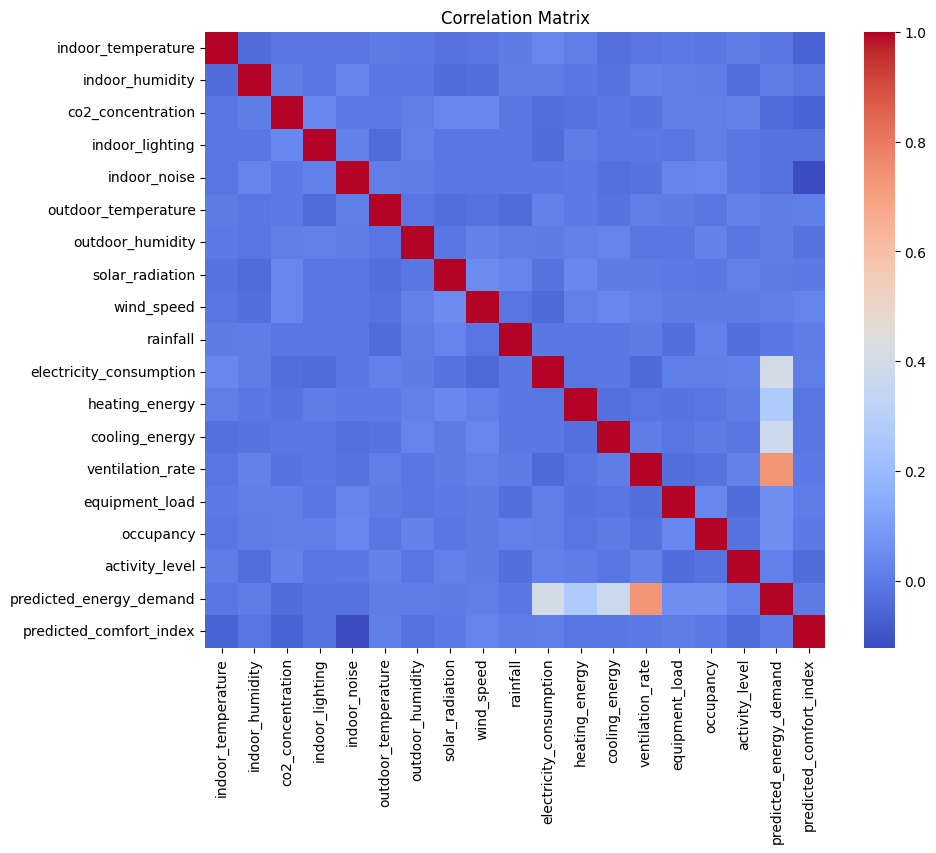

In [29]:
# Plot correlation heatmap
plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")

plt.show()

## Feature Selection

The lecture notes indicate that Linear Regression estimates a linear relationship between predictors and the response variable.

Therefore, predictor variables with relatively strong correlation to predicted_energy_demand are selected.

The selected variables are expected to have a direct influence on building energy consumption.

In [30]:
# Display absolute correlations with target variable
corr_target = corr_matrix['predicted_energy_demand'].abs()

corr_target.sort_values(ascending=False)

,predicted_energy_demand
predicted_energy_demand,1.000000
ventilation_rate,0.728865
electricity_consumption,0.398703
cooling_energy,0.370632
heating_energy,0.271304
equipment_load,0.058766
occupancy,0.057655
co2_concentration,0.036466
indoor_noise,0.024454
indoor_lighting,0.020631


In [31]:
# Select predictor variables
selected_features = [
    'ventilation_rate',
    'equipment_load',
    'heating_energy',
    'cooling_energy',
    'electricity_consumption',
    'occupancy'
]

# Create input matrix
X = df2[selected_features]

# Create target vector
y = df2['predicted_energy_demand']

# Display dimensions
print("Input Shape :", X.shape)


Input Shape : (2400, 6)


## Justification of Selected Parameters

The selected parameters have a direct physical relationship with building energy demand.

- Ventilation Rate influences HVAC operation.
- Equipment Load contributes to internal energy consumption.
- Heating Energy contributes directly to energy demand.
- Cooling Energy contributes directly to energy demand.
- Electricity Consumption reflects overall building energy usage.
- Occupancy affects lighting, equipment usage, and thermal loads.

Therefore, these variables are expected to be suitable predictors for a linear regression model.

In [32]:
# Split data into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Linear Regression Model

According to the lecture notes, Linear Regression estimates model parameters by minimizing the sum of squared residuals between observed and predicted values.

The model is trained using the selected predictor variables.

In [33]:
# Import Linear Regression model
from sklearn.linear_model import LinearRegression

# Create model
model = LinearRegression()

# Train model
model.fit(X_train,y_train)

LinearRegression()

In [34]:
# Display regression coefficients

coefficients = pd.DataFrame({
    'Feature': selected_features,
    'Coefficient': model.coef_
})

coefficients

,Feature,Coefficient
0,ventilation_rate,0.050015
1,equipment_load,0.095229
2,heating_energy,0.249021
3,cooling_energy,0.250241
4,electricity_consumption,0.293144
5,occupancy,0.045714


## Prediction

The trained model is used to estimate energy demand for the unseen test dataset.

In [35]:
# Generate predictions
y_pred = model.predict(X_test)

## Model Evaluation

The performance of the model is evaluated using:

- Mean Absolute Error (MAE)
- Root Mean Square Error (RMSE)
- Coefficient of Determination (R²)

These metrics provide information about prediction accuracy and goodness of fit.

In [36]:
# Import evaluation metrics
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

# Calculate performance metrics
mae = mean_absolute_error(y_test,y_pred)

rmse = np.sqrt(mean_squared_error(y_test,y_pred))

r2 = r2_score(y_test,y_pred)

# Display results
print("MAE :",mae)
print("RMSE:",rmse)
print("R²  :",r2)

MAE : 1.4954039274237645
RMSE: 1.9013855614482615
R²  : 0.9612749268748


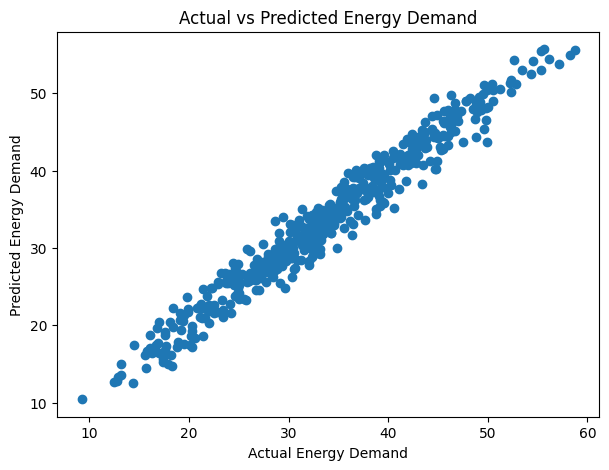

In [37]:
# Plot actual versus predicted values
plt.figure(figsize=(7,5))

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel("Actual Energy Demand")

plt.ylabel("Predicted Energy Demand")

plt.title("Actual vs Predicted Energy Demand")

plt.show()

## Residual Analysis

Residuals represent the difference between observed and predicted values.

A random distribution of residuals around zero suggests that the linear model is appropriate.

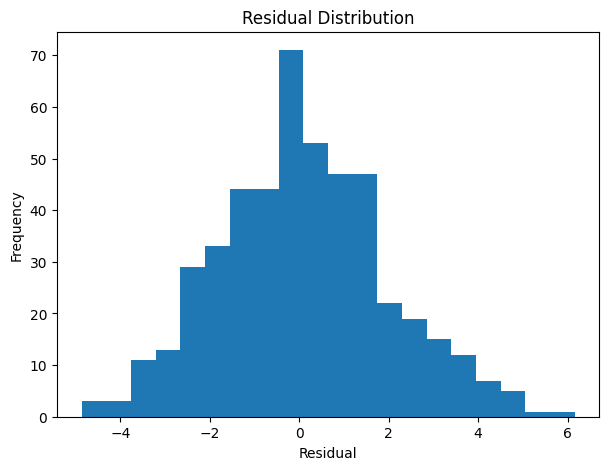

In [38]:
# Calculate residuals

residuals = y_test - y_pred

# Plot residual distribution

plt.figure(figsize=(7,5))

plt.hist(residuals, bins=20)

plt.xlabel("Residual")

plt.ylabel("Frequency")

plt.title("Residual Distribution")

plt.show()

# Discussion

The objective of this study was to investigate whether predicted_energy_demand could be represented using a linear relationship with selected building and environmental parameters.

According to the lecture notes, Linear Regression models the conditional mean of the response variable as a linear combination of predictor variables. The model parameters are estimated by minimizing the sum of squared residuals, which is equivalent to Maximum Likelihood Estimation under Gaussian noise assumptions.

The correlation analysis showed that ventilation rate, equipment load, heating energy, cooling energy, electricity consumption, and occupancy exhibit meaningful relationships with predicted_energy_demand. These variables were selected because they have direct physical connections to building energy consumption and therefore provide a logical basis for prediction.

The regression coefficients provide insight into how each variable contributes to energy demand. Variables such as heating energy, cooling energy, and electricity consumption are expected to have strong positive influence because they directly represent energy-related processes within the building. Occupancy and ventilation rate also contribute indirectly by influencing HVAC and equipment usage.

The evaluation metrics indicate how effectively the selected variables explain variations in predicted_energy_demand. A high R² value suggests that the linear model successfully captures a substantial proportion of the variability in the target variable. The actual-versus-predicted plot provides a visual confirmation of model performance, while the residual analysis helps assess whether the assumptions of Linear Regression are reasonable.

Overall, the results indicate that a significant portion of building energy demand can be explained through a linear relationship with the selected predictor variables.

# Conclusion

The results of this study indicate that predicted_energy_demand can be effectively modeled using a linear relationship with selected building and environmental parameters.

The chosen predictors—ventilation rate, equipment load, heating energy, cooling energy, electricity consumption, and occupancy—were selected based on both their physical relevance and their observed relationship with the target variable.

According to the Linear Regression theory, the model estimates parameters by minimizing the sum of squared residuals, producing the best linear fit to the observed data. The obtained evaluation metrics demonstrate that the selected variables provide substantial predictive information regarding building energy demand.

The Linear Regression framework provides several advantages:

1. It produces an interpretable mathematical relationship between predictors and the response variable.
2. It estimates parameters using the Least Squares principle discussed in the lecture notes.
3. It provides efficient prediction with relatively low computational cost.
4. It allows the contribution of individual variables to be quantified through regression coefficients.

Therefore, based on both the theoretical principles of Linear Regression and the empirical results obtained from the dataset, Linear Regression is a suitable and theoretically justified approach for predicting building energy demand in this dataset.